# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [68]:
#! pip install mne

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

from scripts import global_settings, trial_dynamics, sliding_window, erp_window, trial_dynamics_2, feature

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load Data

In [70]:
# CONDITION   = "BLT"
# ONSET_MS = 500

CONDITION   = "BLA"
ONSET_MS = 0

SUBJECT_IDS = np.setdiff1d(np.arange(1,18,1), [1, 4, 14])
CHANNELS    = "all"                 # T7, T8, TP7, TP8
FREQ_BANDS  = "delta_beta"          # 0.5–30Hz
NORM_DICT = {
    "BASELINE": "pooled_center", # "center", "zscore", None
    "GLOBAL": None,   # "zscore", "max", None
}

all_sub_data = {}
all_data_bc_list = []
all_trial_rows = []

BASELINE_TMIN = -0.500
BASELINE_TMAX = -0.050

for sub_id in SUBJECT_IDS:
    epochs = load_eeg_data(CONDITION, sub_id, channels=CHANNELS, freq_band=FREQ_BANDS)

    data = epochs.get_data() * 1e6   # (n_trials, n_channels, n_times), µV
    times = epochs.times
    ch_names = epochs.ch_names
    sfreq = epochs.info["sfreq"]

    n_trials, n_channels, n_times = data.shape

    baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
    baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
    baseline_std  = data[:, :, baseline_mask].std(axis=-1, keepdims=True)

    baseline_std[baseline_std == 0] = np.nan

    if NORM_DICT["BASELINE"] == "center":
        data_bc = data - baseline_mean
    elif NORM_DICT["BASELINE"] == "zscore":
        data_bc = (data - baseline_mean) / baseline_std   # z-score baseline corrected
    elif NORM_DICT["BASELINE"] == "pooled_center":
        pooled_mean = data[:, :, baseline_mask].mean(axis=(0, 2), keepdims=True)
        data_bc = data - pooled_mean
    elif NORM_DICT["BASELINE"] == "pooled_zscore":
        pooled_mean = data[:, :, baseline_mask].mean(axis=(0, 2), keepdims=True)
        pooled_std  = data[:, :, baseline_mask].std(axis=(0, 2), keepdims=True)
        pooled_std[pooled_std == 0] = np.nan
        data_bc = (data - pooled_mean) / pooled_std
    else:
        data_bc = data

    if NORM_DICT["GLOBAL"] == "zscore":
        global_mean = np.nanmean(data_bc)
        global_std = np.nanstd(data_bc)
        data_bc = (data_bc - global_mean) / global_std
    elif NORM_DICT["GLOBAL"] == "max":
        global_max = np.nanmax(np.abs(data_bc))
        data_bc = data_bc / global_max

    all_sub_data[sub_id] = {
        "epochs": epochs,
        "data": data,
        "data_bc": data_bc,
        "times": times,
        "ch_names": ch_names,
        "sfreq": sfreq,
        "n_trials": n_trials,
        "n_channels": n_channels,
        "n_times": n_times,
    }

    all_data_bc_list.append(data_bc)

    for t in range(n_trials):
        all_trial_rows.append({
            "sub_id": sub_id,
            "trial_index": t + 1,
        })

    print(
        f"Loaded Subject {sub_id} | trials={n_trials}, "
        f"channels={n_channels}, times={n_times}"
    )

ref_sub = SUBJECT_IDS[0]
times = all_sub_data[ref_sub]["times"]
ch_names = all_sub_data[ref_sub]["ch_names"]
time_ms = times * 1000

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 2 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 3 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


...

Loaded Subject 15 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 16 | trials=60, channels=32, times=1792
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/Users/dantelong/Documents/26Spring/PSYC 6745/Physics-of-Cognition_Learning/utils.py:131: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


Loaded Subject 17 | trials=60, channels=32, times=1792


In [71]:
# -------------------------
# 3.1) select channels for ROI grand average
# -------------------------
ROI_NAME = "all_rois"
SELECTED_CHANNELS = global_settings.roi_dict[ROI_NAME]

# -------------------------
# 3) concatenate all subjects after each was corrected separately
# -------------------------
all_data_bc = np.concatenate(all_data_bc_list, axis=0)   # (total_trials, n_channels, n_times)

print("All-subject concatenated data_bc shape:", all_data_bc.shape)



selected_idx = [ch_names.index(ch) for ch in SELECTED_CHANNELS if ch in ch_names]
selected_ch_names = [ch_names[i] for i in selected_idx]

all_data_bc_sel = all_data_bc[:, selected_idx, :]   # (total_trials, n_selected_channels, n_times)

print("Selected channels:", selected_ch_names)
print("all_data_bc_sel shape:", all_data_bc_sel.shape)

# channel-wise grand average on selected channels only
grand_avg_by_channel = np.nanmean(all_data_bc_sel, axis=0)   # (n_selected_channels, T)

# ROI average across selected channels
grand_avg = np.nanmean(grand_avg_by_channel, axis=0)   # (T,)

print("grand_avg_by_channel shape:", grand_avg_by_channel.shape)
print("grand_avg shape:", grand_avg.shape)

All-subject concatenated data_bc shape: (840, 32, 1792)
Selected channels: ['F3', 'FZ', 'F4', 'FC1', 'FC2', 'Cz', 'C3', 'C4', 'CP3', 'CPZ', 'CP4', 'CP1', 'CP2', 'P1', 'P2', 'POz', 'T7', 'T8']
all_data_bc_sel shape: (840, 18, 1792)
grand_avg_by_channel shape: (18, 1792)
grand_avg shape: (1792,)


In [72]:
print(ch_names)

['AF7', 'FPZ', 'AF8', 'AF3', 'AF4', 'F3', 'FZ', 'F4', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP7', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'POz', 'O1', 'Oz', 'O2']


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

           peak_idx  peak_time_ms  peak_amp  search_start_ms  search_end_ms  \
component                                                                     
P50             272     31.250000  0.139232             30.0          100.0   
N100            305     95.703125 -1.376067             80.0          160.0   
P200            349    181.640625  1.455994            150.0          250.0   
N200            419    318.359375 -0.047360            180.0          320.0   
P300            384    250.000000  0.308476            250.0          500.0   

          polarity  final_start_ms  final_end_ms  final_half_width_ms  
component                                                              
P50            pos       16.250000     46.250000                 15.0  
N100           neg       70.703125    120.703125                 25.0  
P200           pos      156.640625    206.640625                 25.0  
N200           neg      293.359375    343.359375                 25.0  
P300          

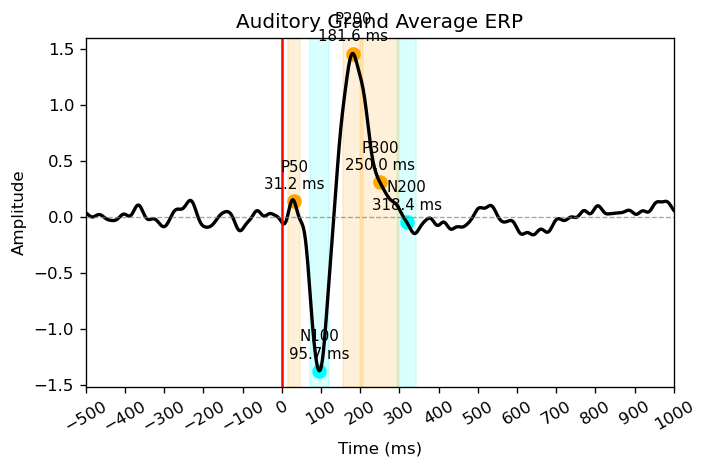

In [73]:
res_aud = erp_window.detect_erp_windows_from_grand_avg(
    time_ms=time_ms,
    grand_avg=grand_avg,
    search_windows=global_settings.SEARCH_DICT[CONDITION]["search_windows"],
    onset_ms = ONSET_MS,
    polarity_map=global_settings.SEARCH_DICT[CONDITION]["polarity_map"],
    half_width_map=global_settings.half_width_map,
    min_time_ms=time_ms.min(),
    max_time_ms=time_ms.max(),
)

print(res_aud)
erp_window.plot_grand_avg_with_windows(
    time_ms=time_ms,
    grand_avg=grand_avg,
    res_df=res_aud,
    title="Auditory Grand Average ERP",
    onset_ms=ONSET_MS,
    figsize=(6,4)
)

## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [74]:
component_windows = {
    comp: {
        "tmin_s": row["final_start_ms"] / 1000.0,
        "tmax_s": row["final_end_ms"] / 1000.0,
        "polarity": row["polarity"],
    }
    for comp, row in res_aud.iterrows()
}

freq_windows = [(0, 500), (500, 1000)]

res = feature.extract_erp_and_freq_features(
    all_sub_data=all_sub_data,
    subject_ids=SUBJECT_IDS,
    selected_channels=SELECTED_CHANNELS,
    res_aud=res_aud,
    freq_windows=freq_windows,
    freq_dict=global_settings.FREQ_BANDS,
    b_relative_band_power=False,
    sfreq=512,
)

In [75]:
erp_features_all_df = res["erp_features_df"]
erp_roi_features_all_df = res["erp_roi_features_df"]
freq_features_all_df = res["freq_features_df"]
freq_roi_features_all_df = res["freq_roi_features_df"]

display(erp_features_all_df.head())
display(erp_roi_features_all_df.head())
display(freq_features_all_df.head())
display(freq_roi_features_all_df.head())

,sub_id,trial_index,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,P200_peak_lat_ms,N200_mean_amp,N200_peak_amp,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms
0,2,1,F3,4.104237,5.334027,35.156250,2.773906,-2.710393,115.234375,6.094768,8.235690,177.734375,0.294533,-2.750681,341.796875,2.143536,7.315765,257.812500
1,2,1,FZ,1.918679,5.122647,42.968750,1.876773,-2.574920,117.187500,7.370012,9.375706,183.593750,-1.514352,-3.699545,294.921875,4.328675,8.573154,201.171875
2,2,1,F4,3.422650,6.737901,44.921875,1.278199,-6.849133,117.187500,3.050766,6.210629,181.640625,5.562593,2.310014,294.921875,4.067082,8.145340,259.765625
3,2,1,FC1,0.760934,4.339910,44.921875,1.325118,-2.181453,117.187500,10.693055,13.160042,177.734375,-0.568993,-2.362343,294.921875,6.982520,11.870383,201.171875
4,2,1,FC2,-1.019417,2.675194,44.921875,-0.548943,-6.839661,119.140625,6.801937,11.556197,205.078125,-0.364303,-1.407212,341.796875,6.881191,11.870172,210.937500


,sub_id,trial_index,P50_mean_amp_roi,P50_peak_amp_roi,P50_peak_lat_ms_roi,N100_mean_amp_roi,N100_peak_amp_roi,N100_peak_lat_ms_roi,P200_mean_amp_roi,P200_peak_amp_roi,P200_peak_lat_ms_roi,N200_mean_amp_roi,N200_peak_amp_roi,N200_peak_lat_ms_roi,P300_mean_amp_roi,P300_peak_amp_roi,P300_peak_lat_ms_roi
0,2,1,3.346726e-09,2.633721,29.113770,-6.316089e-08,-4.419588,93.505859,3.271463e-08,5.542910,179.016113,4.668564e-08,-2.700888,323.120117,4.661254e-08,4.867493,259.826660
1,2,2,-2.638456e-09,1.821514,31.799316,1.006294e-08,-4.227944,92.346191,3.473484e-08,4.474503,181.762695,-2.676225e-09,-3.959307,320.373535,5.503822e-09,6.428736,243.896484
2,2,3,3.385285e-09,3.034430,30.090332,-2.771491e-08,-5.138593,98.022461,2.286176e-08,5.622754,182.128906,-1.382311e-08,-5.702564,322.265625,3.247676e-08,7.485134,237.731934
3,2,4,1.374619e-08,2.843922,33.935547,8.820330e-08,-2.785272,91.369629,-4.771513e-08,5.205558,185.913086,-2.988858e-08,-3.052410,318.237305,8.556387e-09,5.545772,240.051270
4,2,5,-2.726244e-08,2.263724,30.700684,5.290119e-08,-4.341662,98.083496,1.113737e-08,3.792952,183.654785,-4.047034e-08,-3.774873,318.908691,-1.957881e-09,4.594175,239.501953


,sub_id,trial_index,channel,fw0_theta_power,fw0_alpha_power,fw0_beta_power,fw1_theta_power,fw1_alpha_power,fw1_beta_power
0,2,1,F3,2.358863,1.670827,4.846680,2.686739,0.168369,1.806733
1,2,1,FZ,5.856990,1.077582,2.439631,1.823493,1.061447,1.670921
2,2,1,F4,1.434019,1.056228,3.887856,1.924678,3.755590,2.433127
3,2,1,FC1,9.802768,1.455690,3.981608,1.181820,0.509266,2.043032
4,2,1,FC2,10.183145,1.158635,1.962479,0.922308,1.721021,1.526135


,sub_id,trial_index,fw0_0_500ms_theta_power_roi,fw0_0_500ms_alpha_power_roi,fw0_0_500ms_beta_power_roi,fw1_500_1000ms_theta_power_roi,fw1_500_1000ms_alpha_power_roi,fw1_500_1000ms_beta_power_roi
0,2,1,6.190512,1.089150,2.502111,1.401668,1.094216,3.581619
1,2,2,4.309866,1.316698,5.127232,3.279183,1.148395,4.150871
2,2,3,12.539548,3.370664,5.621556,2.200103,1.723481,3.702343
3,2,4,4.691343,1.837073,1.945474,5.549280,1.056492,3.483877
4,2,5,1.683674,1.870702,3.643619,1.727447,0.891065,5.530488


In [76]:
print("len(ch_names):", len(ch_names))
print("grand_avg_by_channel.shape:", grand_avg_by_channel.shape)

len(ch_names): 32
grand_avg_by_channel.shape: (18, 1792)


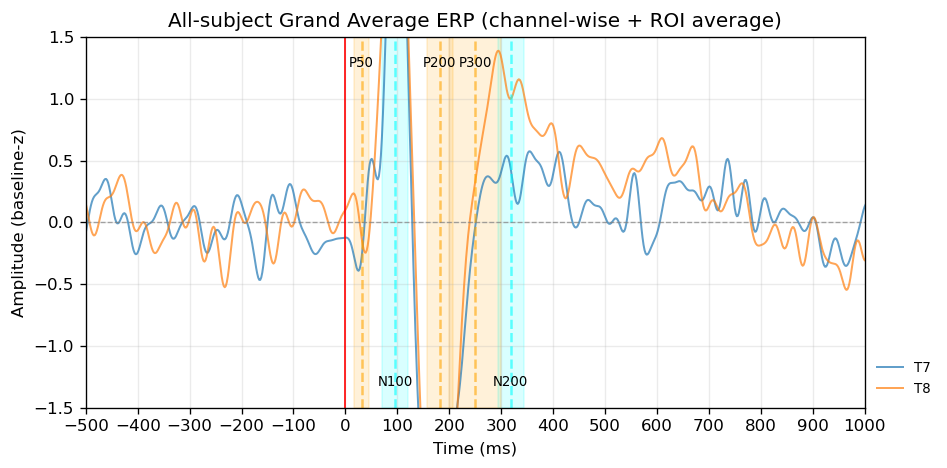

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))
observe_range = 1.5
for c, ch in enumerate(SELECTED_CHANNELS):
    if ch not in ("T7", "T8"):
        continue

    ax.plot(
        time_ms,
        grand_avg_by_channel[c],
        linewidth=1.2,
        alpha=0.7,
        label=ch
    )

# ax.plot(
#     time_ms,
#     grand_avg,
#     color="black",
#     linewidth=3,
#     label="ROI average"
# )

min_amp = np.nanmin(grand_avg)
max_amp = np.nanmax(grand_avg)

for comp, row in res_aud.iterrows():
    color = "orange" if row["polarity"] == "pos" else "cyan"
    text_pos_y = -observe_range * 0.9 if row["polarity"] == "neg" else observe_range * 0.9
    ax.axvspan(
        row["final_start_ms"],
        row["final_end_ms"],
        alpha=0.15,
        color=color
    )
    ax.axvline(row["peak_time_ms"], linestyle="--", alpha=0.6, color=color)
    
    ax.text(
        row["peak_time_ms"],
        text_pos_y,
        comp,
        fontsize=8,
        ha="center",
        va="bottom" if row["polarity"] == "neg" else "top",
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
ax.axvline(ONSET_MS, color="red", linestyle="-", linewidth=1, alpha=1.0)

ax.set_title("All-subject Grand Average ERP (channel-wise + ROI average)")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude (baseline-z)")
ax.set_xlim(-500+ONSET_MS, 800+ONSET_MS)
ax.set_xticks(np.arange(-500+ONSET_MS, 1001+ONSET_MS, 100))
ax.set_ylim(-observe_range, observe_range)
ax.grid(True, alpha=0.25)
ax.legend(loc="lower left", bbox_to_anchor=(1.0, 0), fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

In [78]:
print(erp_features_all_df.shape[0])
print(freq_features_all_df.shape[0])
assert erp_features_all_df.shape[0] == freq_features_all_df.shape[0], "not the same"

merged_df = pd.merge(
    erp_features_all_df,
    freq_features_all_df,
    on=["sub_id", "trial_index", "channel"],
    how="inner"
)

display(merged_df.head())

15120
15120


,sub_id,trial_index,channel,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,...,N200_peak_lat_ms,P300_mean_amp,P300_peak_amp,P300_peak_lat_ms,fw0_theta_power,fw0_alpha_power,fw0_beta_power,fw1_theta_power,fw1_alpha_power,fw1_beta_power
0,2,1,F3,4.104237,5.334027,35.156250,2.773906,-2.710393,115.234375,6.094768,...,341.796875,2.143536,7.315765,257.812500,2.358863,1.670827,4.846680,2.686739,0.168369,1.806733
1,2,1,FZ,1.918679,5.122647,42.968750,1.876773,-2.574920,117.187500,7.370012,...,294.921875,4.328675,8.573154,201.171875,5.856990,1.077582,2.439631,1.823493,1.061447,1.670921
2,2,1,F4,3.422650,6.737901,44.921875,1.278199,-6.849133,117.187500,3.050766,...,294.921875,4.067082,8.145340,259.765625,1.434019,1.056228,3.887856,1.924678,3.755590,2.433127
3,2,1,FC1,0.760934,4.339910,44.921875,1.325118,-2.181453,117.187500,10.693055,...,294.921875,6.982520,11.870383,201.171875,9.802768,1.455690,3.981608,1.181820,0.509266,2.043032
4,2,1,FC2,-1.019417,2.675194,44.921875,-0.548943,-6.839661,119.140625,6.801937,...,341.796875,6.881191,11.870172,210.937500,10.183145,1.158635,1.962479,0.922308,1.721021,1.526135


In [79]:
erp_roi_features_df, erp_roi_roll_df, erp_roi_group_roll_df = sliding_window.aggregate(
    merged_df,
    component_windows=component_windows,
    ROI_NAME=ROI_NAME,
    CONDITION=CONDITION,
)

CONDITION = all_rois
Subregions: ['F', 'FC', 'C', 'CP', 'P', 'PO', 'T']
Detected 21 feature columns.
Feature columns: ['P50_mean_amp', 'P50_peak_amp', 'P50_peak_lat_ms', 'N100_mean_amp', 'N100_peak_amp', 'N100_peak_lat_ms', 'P200_mean_amp', 'P200_peak_amp', 'P200_peak_lat_ms', 'N200_mean_amp', 'N200_peak_amp', 'N200_peak_lat_ms', 'P300_mean_amp', 'P300_peak_amp', 'P300_peak_lat_ms', 'fw0_theta_power', 'fw0_alpha_power', 'fw0_beta_power', 'fw1_theta_power', 'fw1_alpha_power', 'fw1_beta_power']

Processing region = F, channels = ['F3', 'FZ', 'F4']

Processing region = FC, channels = ['FC1', 'FC2']

Processing region = C, channels = ['C3', 'Cz', 'C4']

Processing region = CP, channels = ['CP3', 'CPZ', 'CP4']

Processing region = P, channels = ['P1', 'P2']

Processing region = PO, channels = ['POz']

Processing region = T, channels = ['T7', 'T8']

[Per-subject region-aggregated features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,...,P300_peak_amp,P300_peak_lat_ms,fw0_theta_power,fw0_alpha_power,fw0_beta_power,fw1_theta_power,fw1_alpha_power,fw1_beta_power,condition,region
0,2,1,3.148522,5.731525,41.015625,1.976293,-4.044815,116.536458,5.505182,7.940675,...,8.011419,239.583333,3.216624,1.268213,3.724722,2.144970,1.661802,1.970260,BLA,F
1,2,2,3.171825,5.832943,20.182292,2.729768,-0.443435,110.026042,3.306353,7.708669,...,6.725306,241.536458,1.965823,1.285734,5.982387,3.575456,0.612162,2.368133,BLA,F
2,2,3,10.486686,13.259097,38.411458,5.311687,-0.417801,118.489583,6.160134,11.856963,...,14.095423,238.932292,13.925944,1.992026,5.160817,2.984429,2.960641,2.794727,BLA,F
3,2,4,0.394036,2.832959,25.390625,-11.860999,-14.597960,104.817708,-8.202789,0.452873,...,1.101211,236.328125,5.043546,3.963383,1.711491,12.751249,1.626298,3.037971,BLA,F
4,2,5,8.519373,9.468429,32.552083,-0.469008,-4.179094,119.140625,-0.894680,2.379155,...,1.372461,212.239583,0.859964,2.554588,2.241284,1.981766,0.785333,3.821275,BLA,F



[Per-subject rolling features]


,sub_id,trial_index,P50_mean_amp,P50_peak_amp,P50_peak_lat_ms,N100_mean_amp,N100_peak_amp,N100_peak_lat_ms,P200_mean_amp,P200_peak_amp,...,N200_peak_lat_ms_roll,P300_mean_amp_roll,P300_peak_amp_roll,P300_peak_lat_ms_roll,fw0_theta_power_roll,fw0_alpha_power_roll,fw0_beta_power_roll,fw1_theta_power_roll,fw1_alpha_power_roll,fw1_beta_power_roll
0,2,1,3.148522,5.731525,41.015625,1.976293,-4.044815,116.536458,5.505182,7.940675,...,316.840278,3.745012,9.610716,240.017361,6.369464,1.515324,4.955976,2.901618,1.744868,2.377707
1,2,2,3.171825,5.832943,20.182292,2.729768,-0.443435,110.026042,3.306353,7.708669,...,314.453125,1.257527,7.483340,239.095052,6.037984,2.127339,4.144854,5.364026,1.715226,2.542773
2,2,3,10.486686,13.259097,38.411458,5.311687,-0.417801,118.489583,6.160134,11.856963,...,317.187500,0.354362,6.261164,233.723958,5.002380,2.212789,3.764140,4.687574,1.529247,2.798473
3,2,4,0.394036,2.832959,25.390625,-11.860999,-14.597960,104.817708,-8.202789,0.452873,...,321.614583,-0.364458,5.493939,236.718750,4.730406,2.601557,3.495327,5.789707,1.791534,4.309307
4,2,5,8.519373,9.468429,32.552083,-0.469008,-4.179094,119.140625,-0.894680,2.379155,...,324.739583,-1.357166,4.666377,243.098958,4.854208,2.782166,3.115803,6.487543,1.924529,5.626557



[Grand average rolling features]


,trial_index,condition,region,P50_mean_amp_roll_mean,P50_mean_amp_roll_sem,P50_peak_amp_roll_mean,P50_peak_amp_roll_sem,P50_peak_lat_ms_roll_mean,P50_peak_lat_ms_roll_sem,N100_mean_amp_roll_mean,...,fw0_alpha_power_roll_mean,fw0_alpha_power_roll_sem,fw0_beta_power_roll_mean,fw0_beta_power_roll_sem,fw1_theta_power_roll_mean,fw1_theta_power_roll_sem,fw1_alpha_power_roll_mean,fw1_alpha_power_roll_sem,fw1_beta_power_roll_mean,fw1_beta_power_roll_sem
0,1,BLA,C,0.138120,0.686014,2.852799,0.684693,30.180432,1.288592,-4.312303,...,5.056533,1.633415,3.146602,0.436649,2.088137,0.350640,2.681605,0.539574,3.440956,0.583051
1,2,BLA,C,0.530276,0.621315,3.214139,0.649526,30.378069,1.327392,-4.275314,...,5.553575,1.706250,3.101792,0.519481,2.204477,0.395024,3.313724,0.901956,3.553475,0.526312
2,3,BLA,C,0.540289,0.601422,3.282988,0.618619,31.305804,1.138630,-4.443053,...,5.991291,1.751353,3.030285,0.453954,2.106183,0.345755,4.449617,1.296754,3.472018,0.482328
3,4,BLA,C,1.199667,0.478150,3.999885,0.639364,32.263765,1.398207,-4.762619,...,6.582622,2.225928,3.054376,0.434152,2.357403,0.401967,5.459577,1.968649,3.596064,0.494909
4,5,BLA,C,1.072965,0.499991,3.903660,0.604488,32.356771,1.081570,-5.025710,...,6.577359,2.036200,3.120921,0.416223,2.334781,0.392721,6.020149,2.420254,3.440885,0.461734


In [80]:
erp_roi_roll_df.to_csv("output/erp_roi_rolling_features.csv", index=False)

In [81]:
erp_feature_cols = [
    "P50_mean_amp", "P50_peak_amp", "P50_peak_lat_ms",
    "N100_mean_amp", "N100_peak_amp", "N100_peak_lat_ms",
    "P200_mean_amp", "P200_peak_amp", "P200_peak_lat_ms",
    "N200_mean_amp", "N200_peak_amp", "N200_peak_lat_ms",
    "P300_mean_amp", "P300_peak_amp", "P300_peak_lat_ms",
]

freq_feature_cols = [
    f"fw{fw_idx}_{band}_power"
    for fw_idx in range(len(freq_windows))
    for band in global_settings.FREQ_BANDS.keys()
]

feature_cols = erp_feature_cols + freq_feature_cols

res = trial_dynamics_2.run_erp_synergy_pipeline(
    df=erp_roi_features_df,
    feature_cols=feature_cols,
    region_col="region",
    sub_col="sub_id",
    trial_col="trial_index",
    zscore_within_subject=True,
    pca_n_components=3,
    multiblock_method="cca",
    multiblock_n_components=3,
)

In [82]:
print(res.keys())

dict_keys(['df_resid', 'beta_df', 'corr_raw', 'corr_resid', 'pca_res', 'feature_cols', 'resid_cols', 'block_dict', 'multiblock_res', 'multiblock_amp_lat_res', 'multiblock_amp_freq_res', 'multiblock_lat_freq_res'])


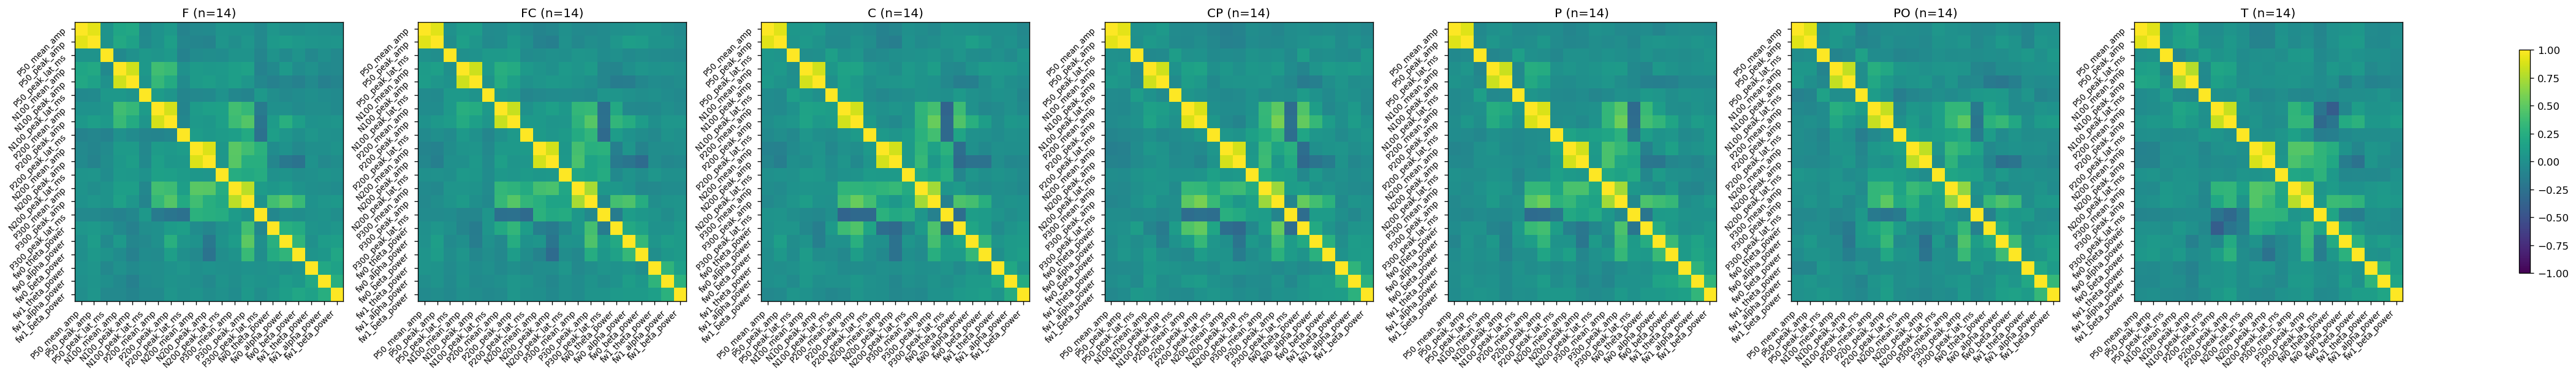

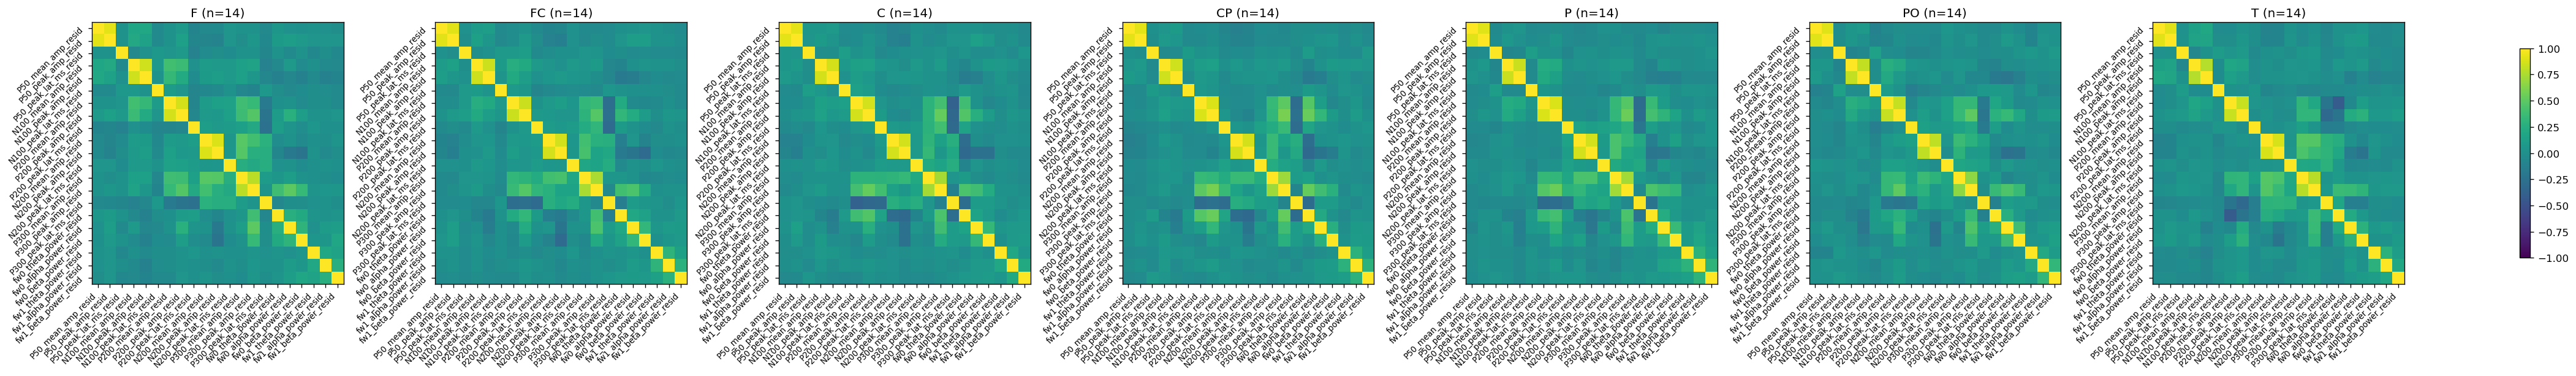

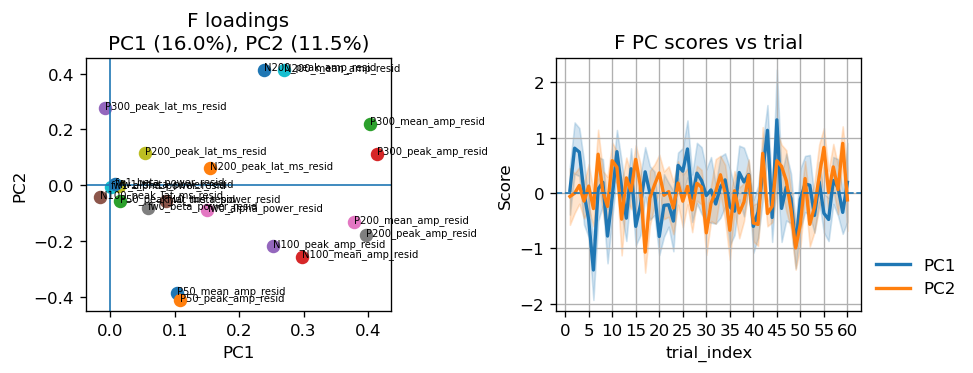

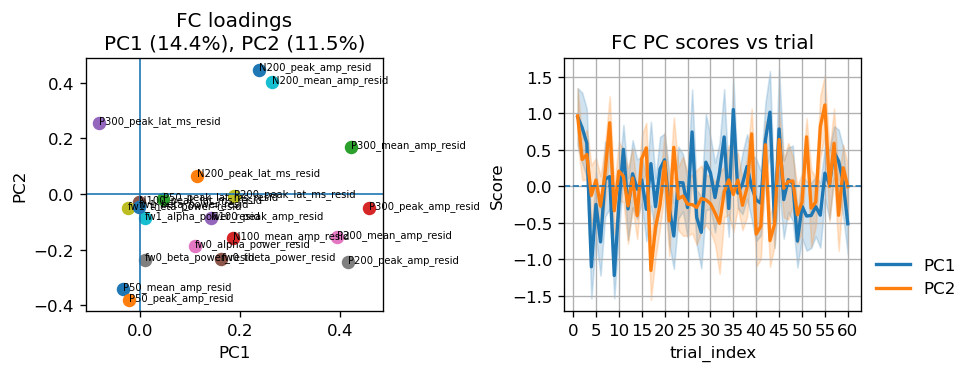

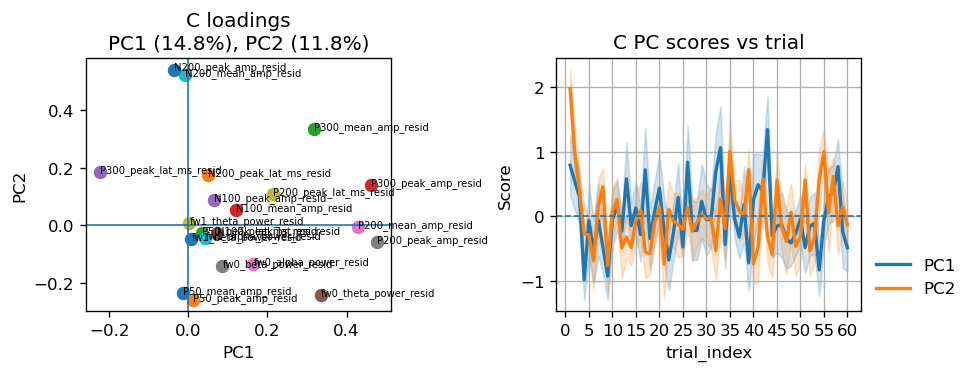

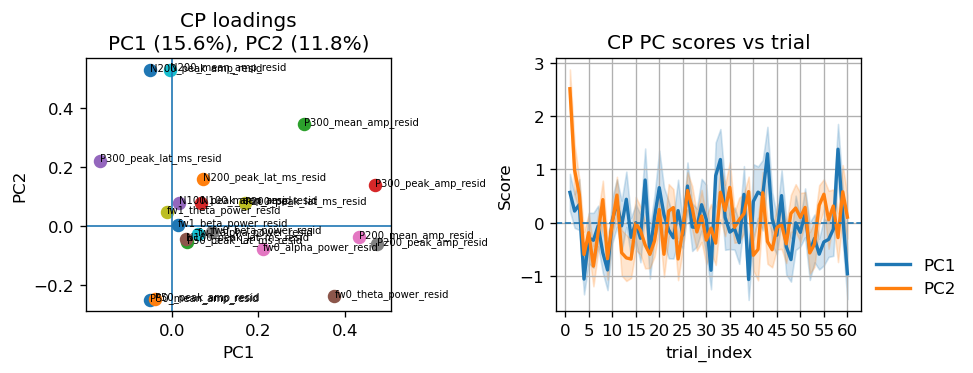

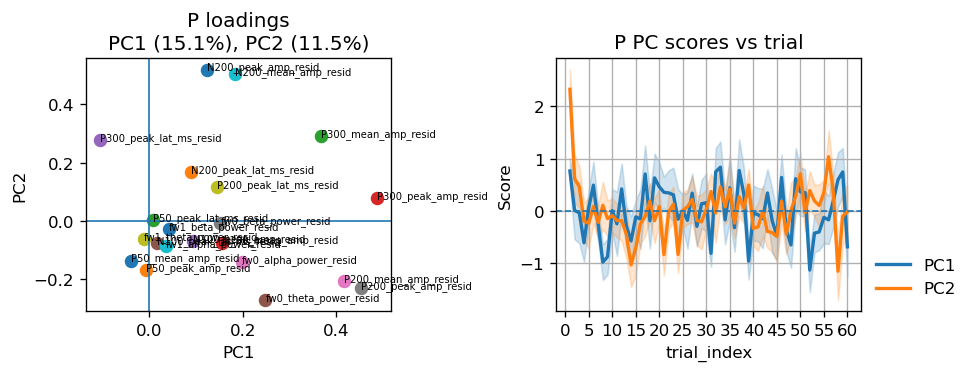

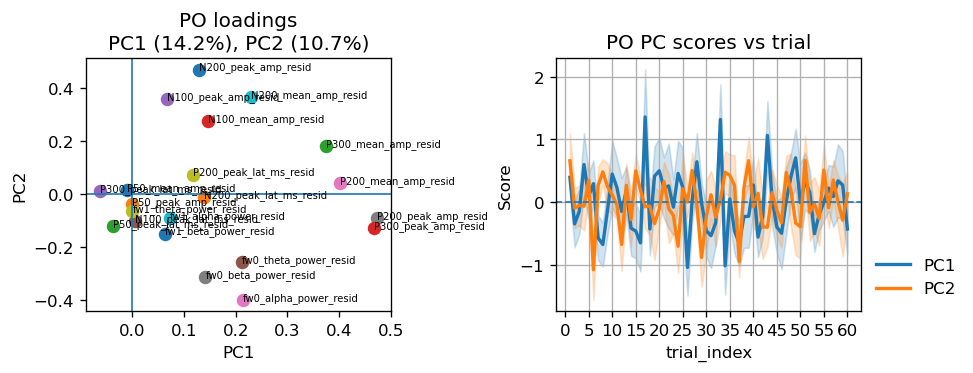

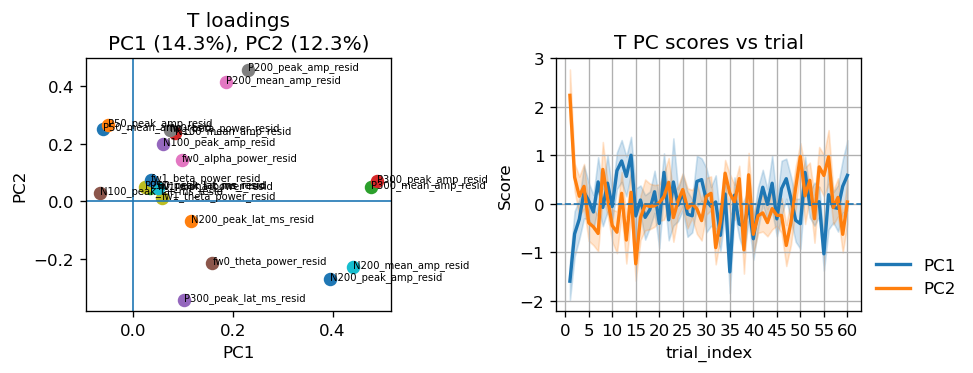

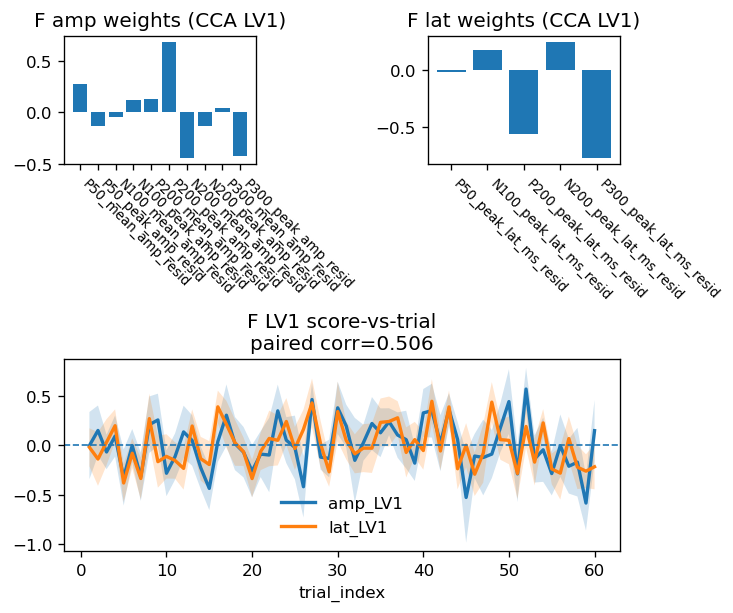

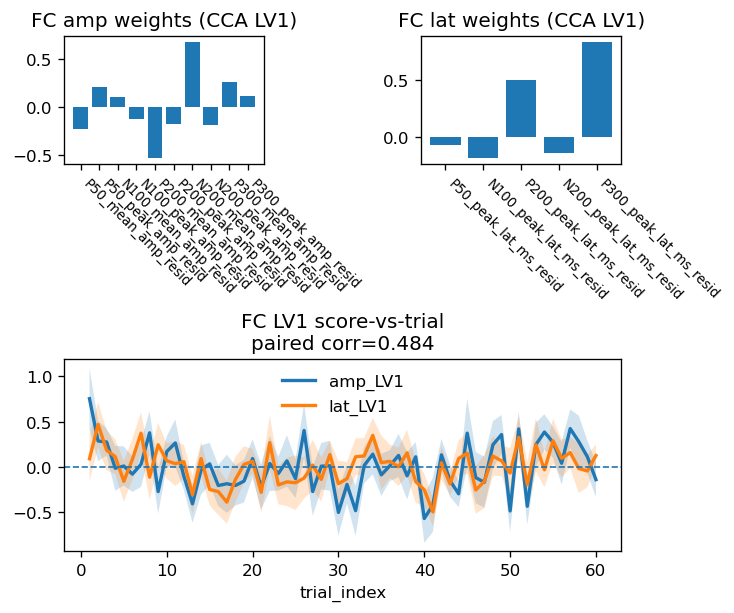

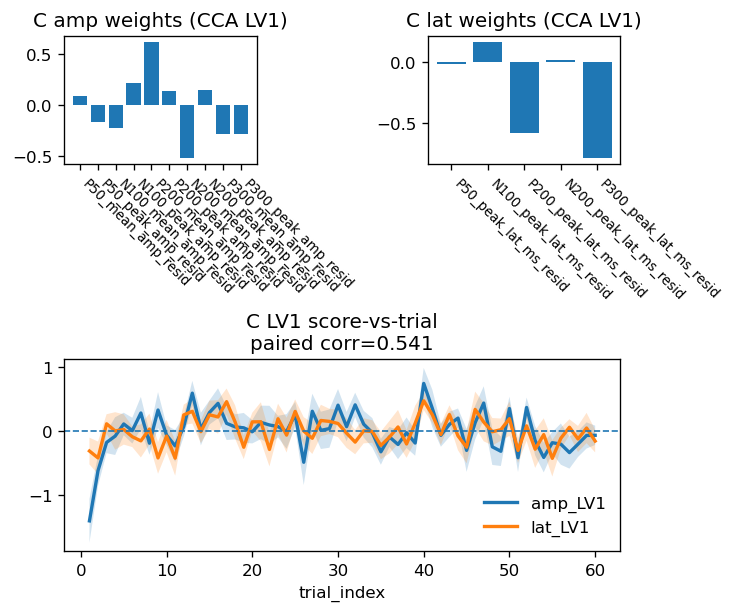

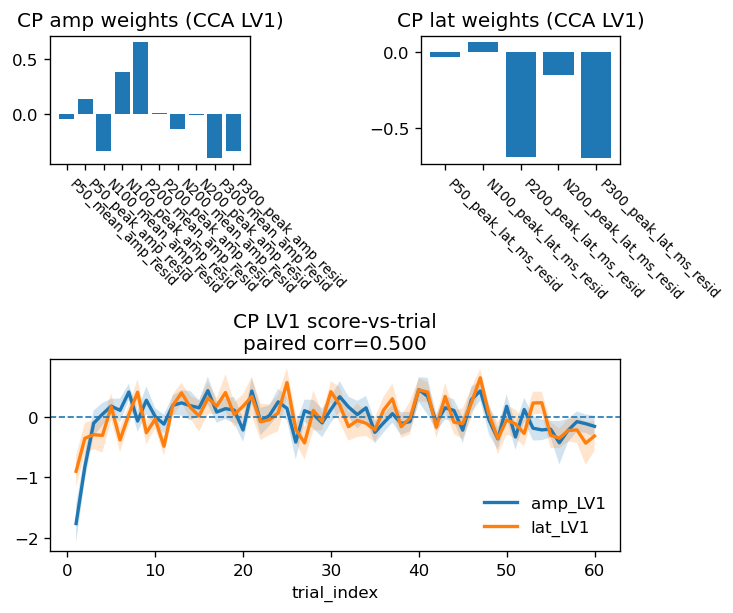

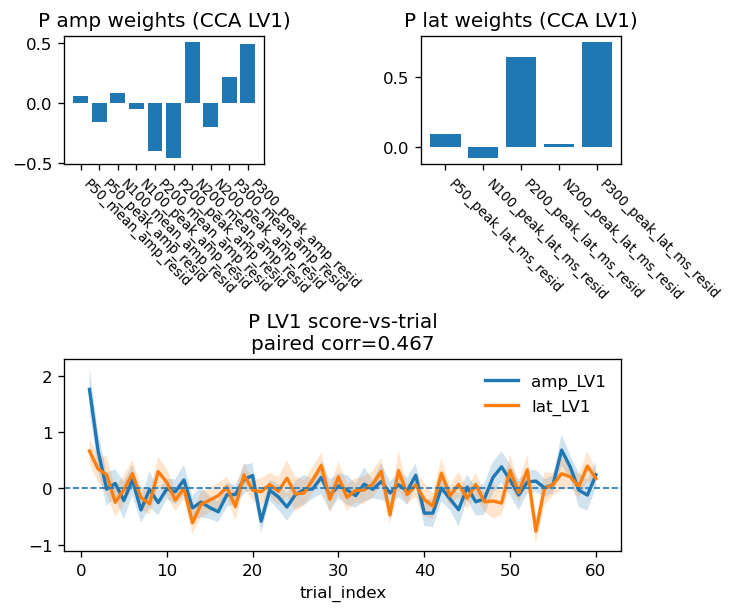

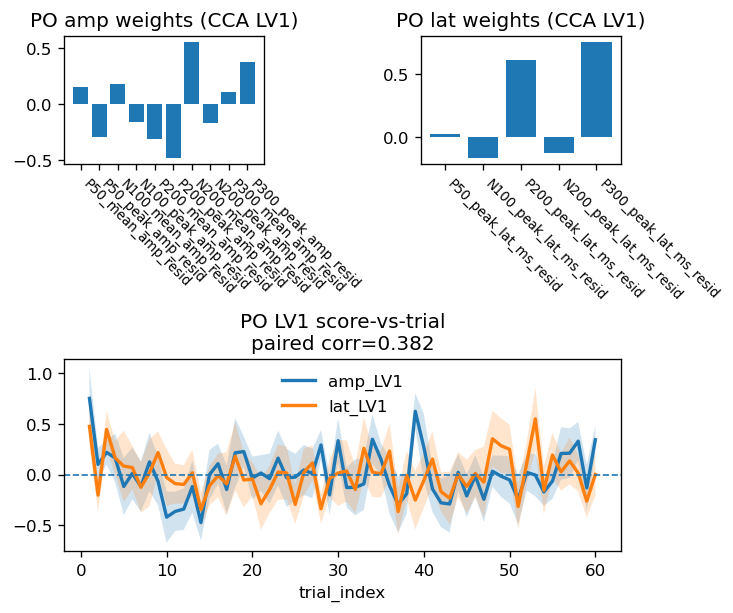

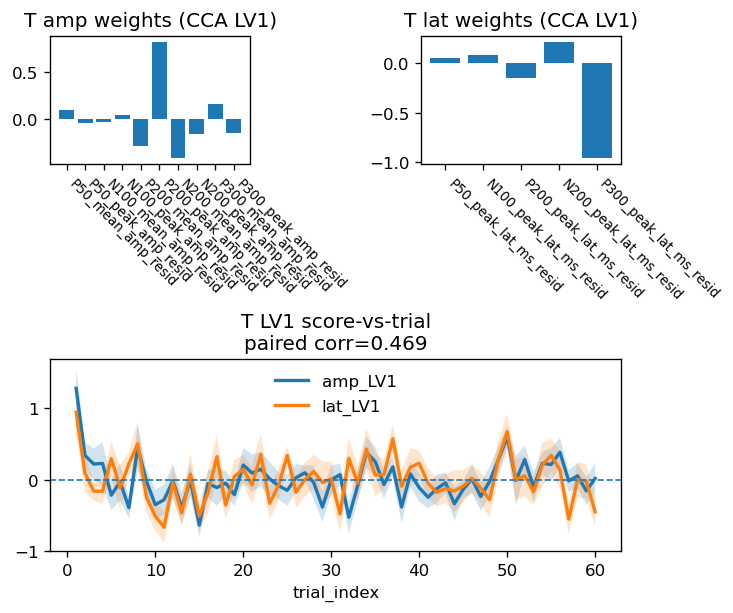

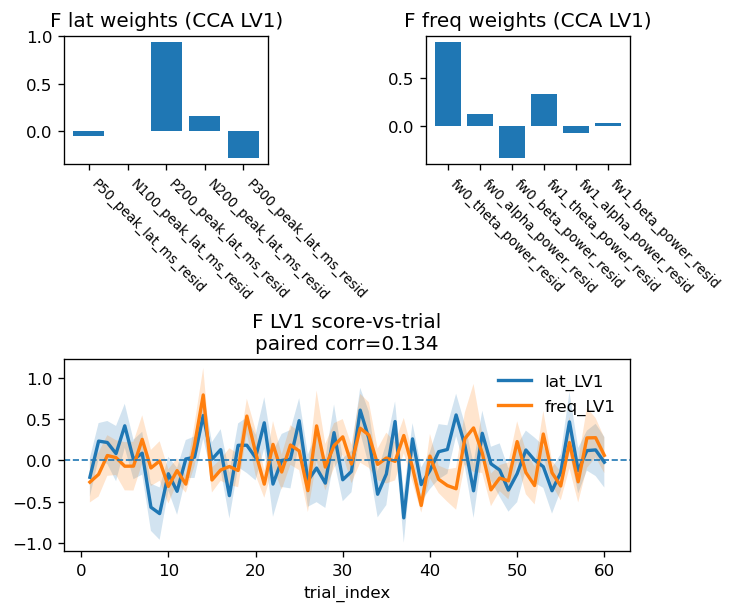

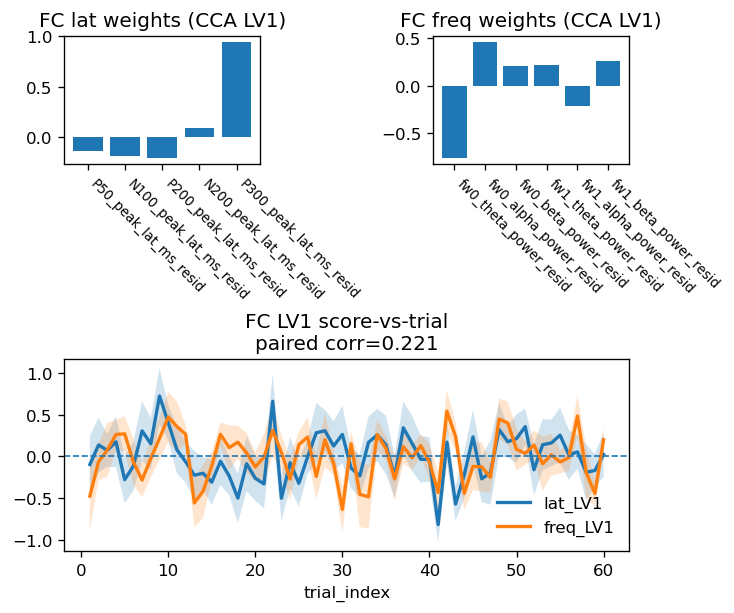

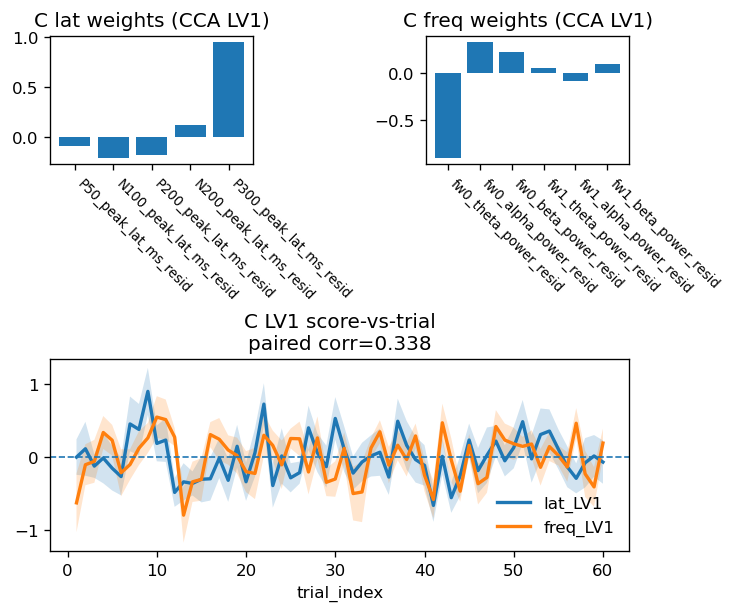

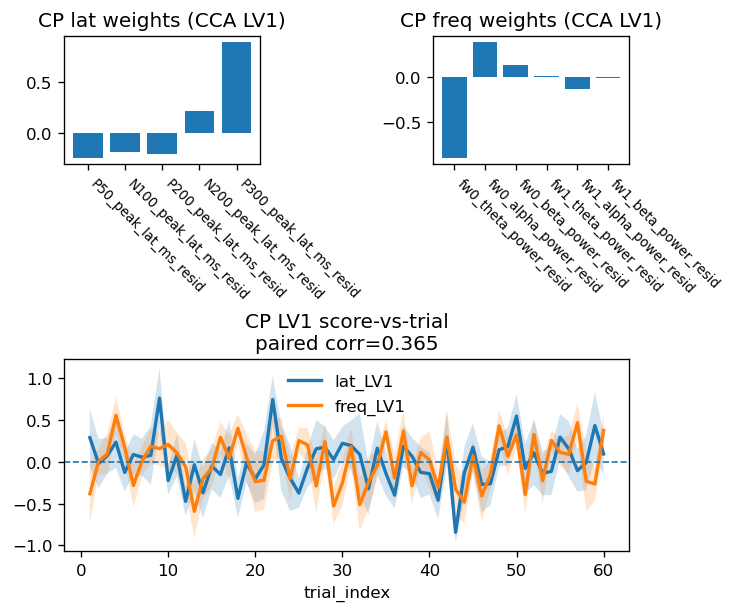

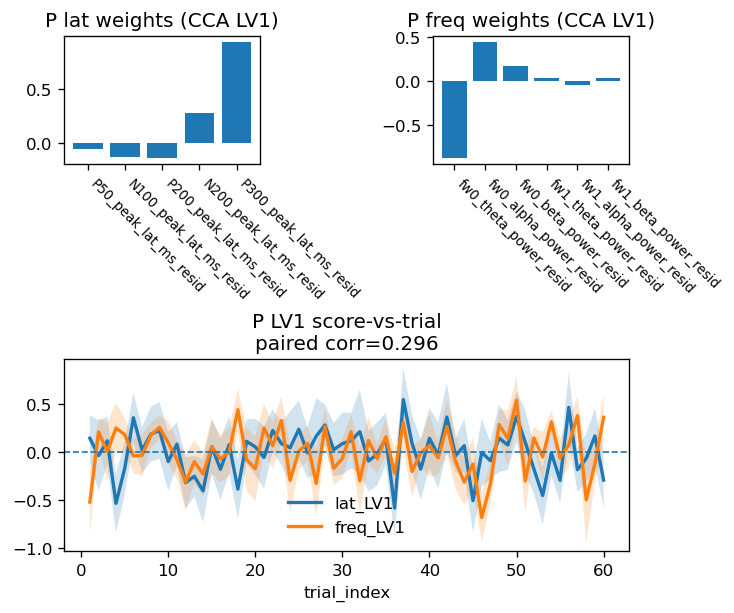

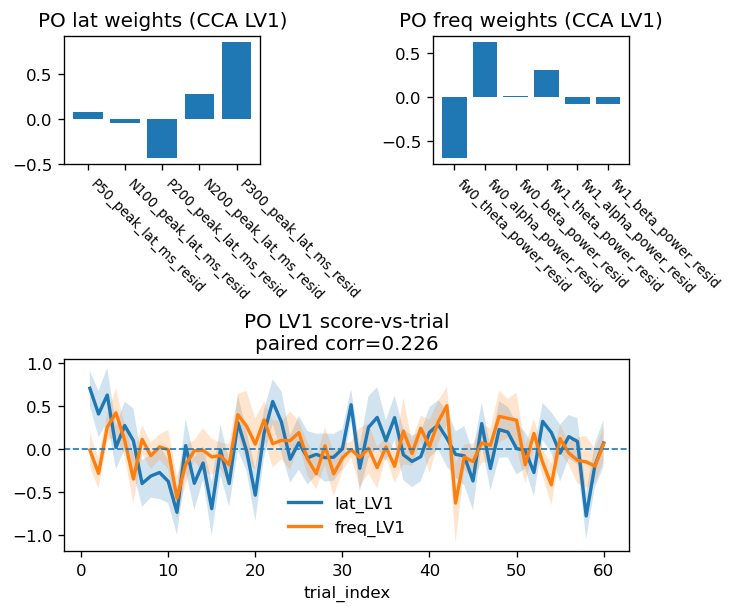

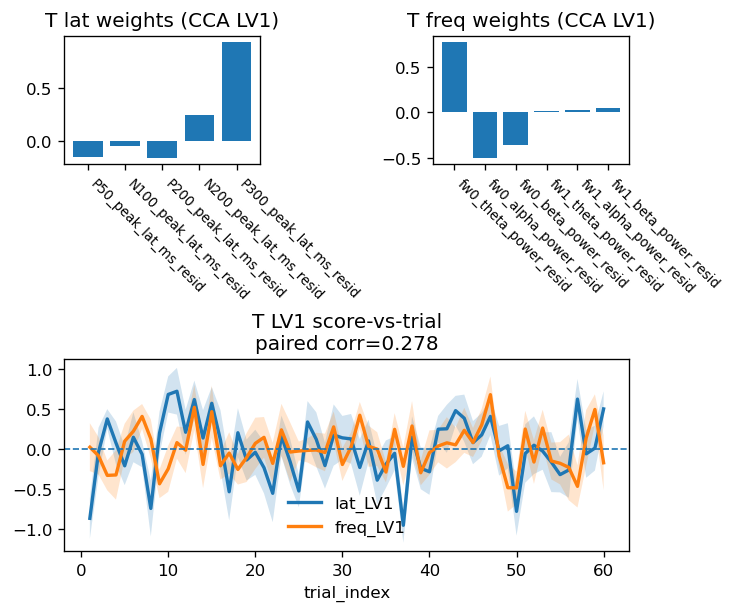

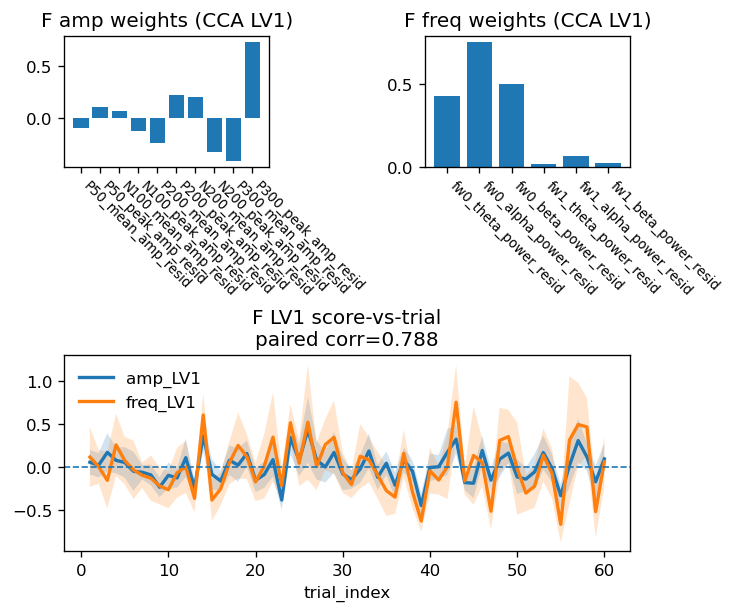

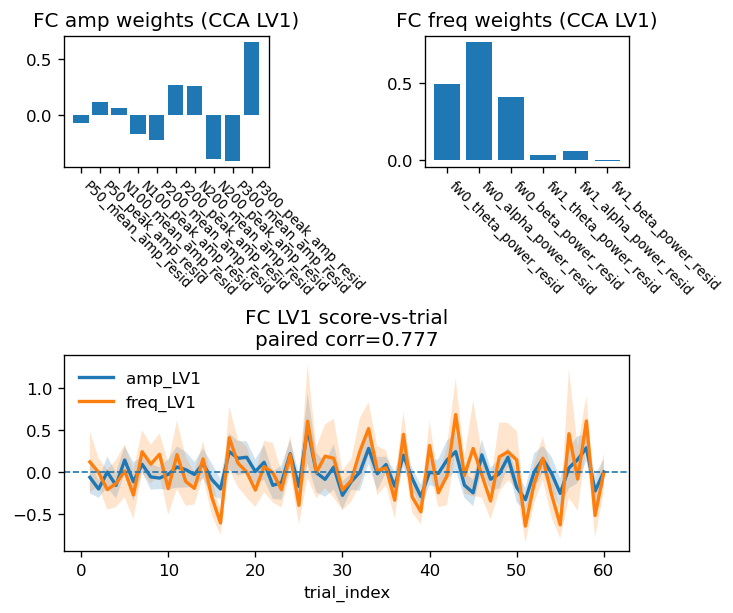

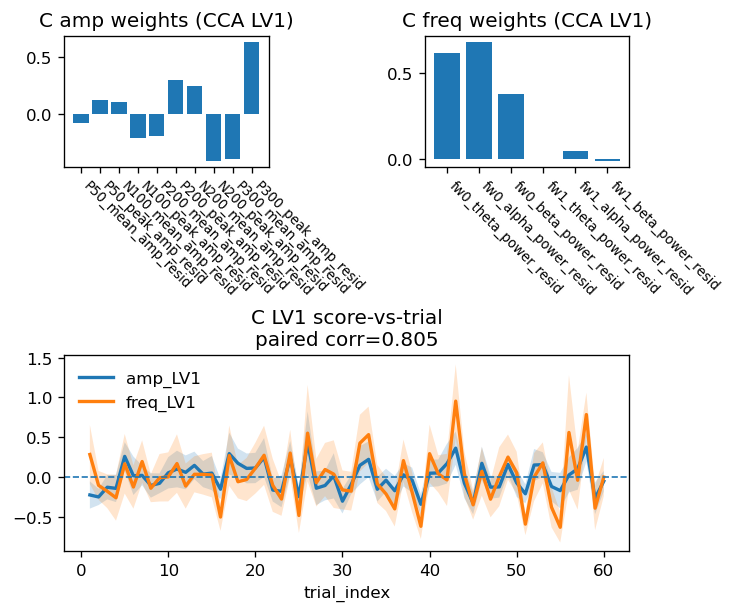

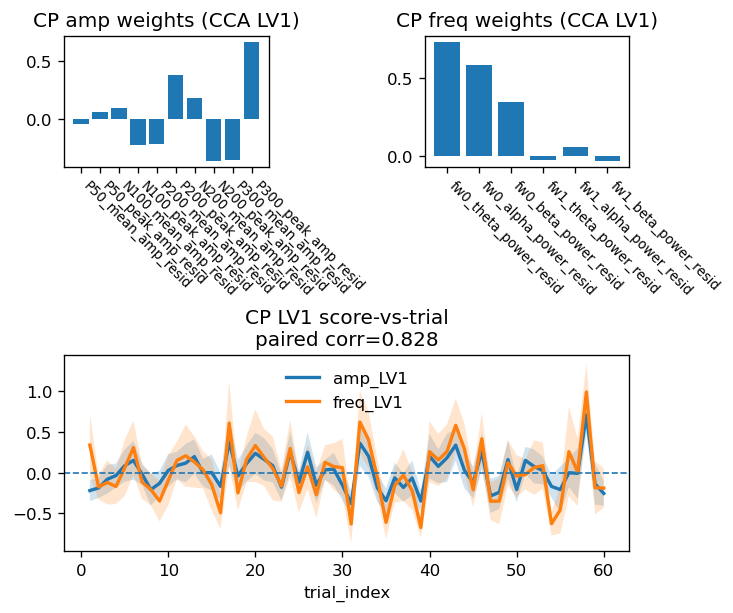

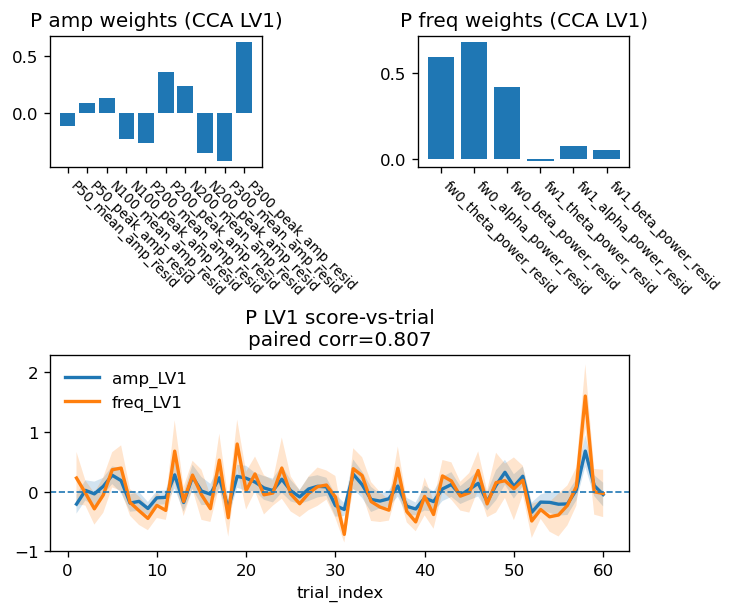

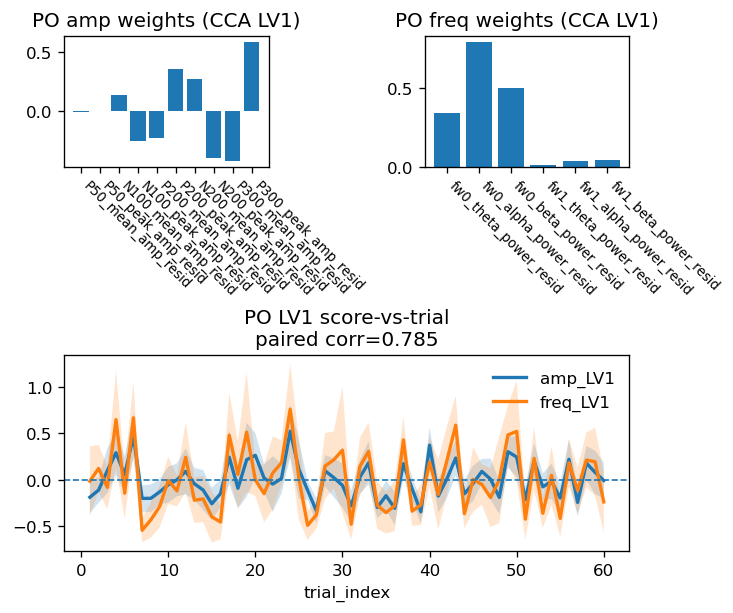

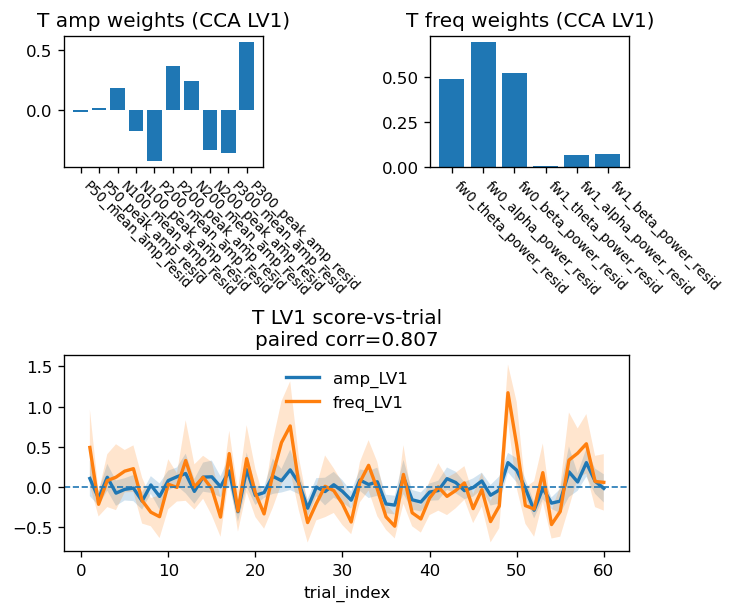

In [85]:
trial_dynamics_2.plot_group_correlation_matrices(res["corr_raw"], figsize_per_region=(5,5))
trial_dynamics_2.plot_group_correlation_matrices(res["corr_resid"], figsize_per_region=(5,5))
trial_dynamics_2.plot_pca_loadings_and_scores(
    res["pca_res"],
    pc_x="PC1",
    pc_y="PC2",
    pcs=(1,2,),
    trial_col="trial_index",
    sub_col="sub_id",
)

trial_dynamics_2.plot_multiblock_results(
    res["multiblock_amp_lat_res"],
    lv=1,
    trial_col="trial_index",
)

trial_dynamics_2.plot_multiblock_results(
    res["multiblock_lat_freq_res"],
    lv=1,
    trial_col="trial_index",
)

trial_dynamics_2.plot_multiblock_results(
    res["multiblock_amp_freq_res"],
    lv=1,
    trial_col="trial_index",
)

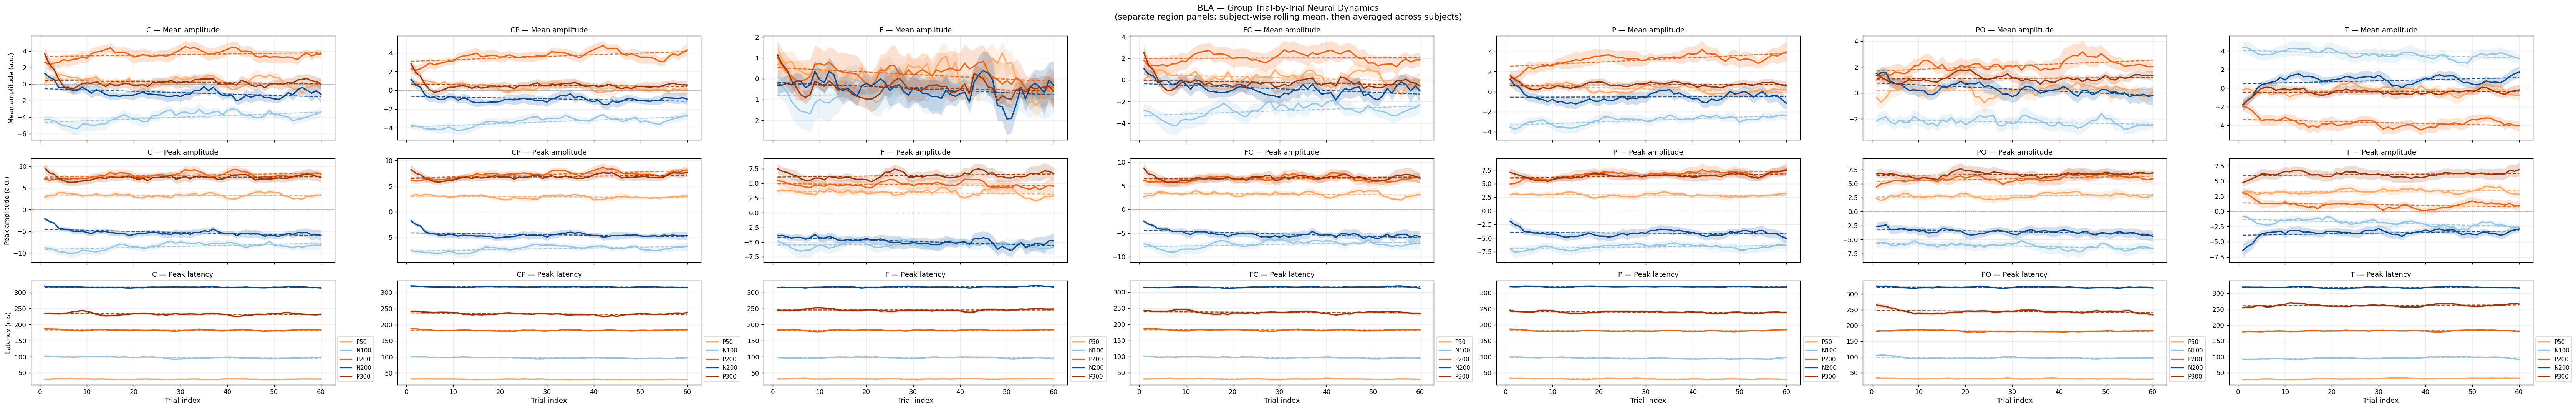

,region,component,metric_suffix,metric_title,mean_col,slope,intercept,rvalue,r2,pvalue,stderr,n
0,C,P50,mean_amp_roll_mean,Mean amplitude,P50_mean_amp_roll_mean,-0.010936,0.651232,-0.354459,0.125641,5.457410e-03,0.003788,60
1,C,N100,mean_amp_roll_mean,Mean amplitude,N100_mean_amp_roll_mean,0.021076,-4.639269,0.603569,0.364295,3.312762e-07,0.003656,60
2,C,P200,mean_amp_roll_mean,Mean amplitude,P200_mean_amp_roll_mean,0.007748,3.335650,0.271853,0.073904,3.562219e-02,0.003601,60
3,C,N200,mean_amp_roll_mean,Mean amplitude,N200_mean_amp_roll_mean,-0.016257,-0.546838,-0.465603,0.216786,1.777171e-04,0.004057,60
4,C,P300,mean_amp_roll_mean,Mean amplitude,P300_mean_amp_roll_mean,-0.006909,0.435721,-0.185602,0.034448,1.556671e-01,0.004803,60
...,...,...,...,...,...,...,...,...,...,...,...,...
100,T,P50,peak_lat_ms_roll_mean,Peak latency,P50_peak_lat_ms_roll_mean,0.060887,29.561428,0.774780,0.600283,3.760879e-13,0.006524,60
101,T,N100,peak_lat_ms_roll_mean,Peak latency,N100_peak_lat_ms_roll_mean,0.100513,93.078102,0.697966,0.487157,5.711594e-10,0.013542,60
102,T,P200,peak_lat_ms_roll_mean,Peak latency,P200_peak_lat_ms_roll_mean,0.037910,180.734451,0.414762,0.172028,9.844998e-04,0.010921,60
103,T,N200,peak_lat_ms_roll_mean,Peak latency,N200_peak_lat_ms_roll_mean,-0.000566,318.376707,-0.005266,0.000028,9.681482e-01,0.014122,60


In [84]:
res_df = trial_dynamics.plot_group_trial_dynamics(
    erp_roi_group_roll_df=erp_roi_group_roll_df,
    component_windows=component_windows,
    CONDITION=CONDITION,
    group_col="region",
    b_plot_channel_seperate=True,
    b_fit_linear=True,
    b_plot_fit=True,
)
display(res_df)

res_df.to_csv(f"output/{CONDITION}_{ROI_NAME}_trial_dynamics_results.csv", index=False)